In [2]:
# 필요한 라이브러리 설치
!pip install opencv-python pixellib

In [3]:
# 라이브러리 import
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


원본 고양이 이미지 크기: (1305, 1205, 3)


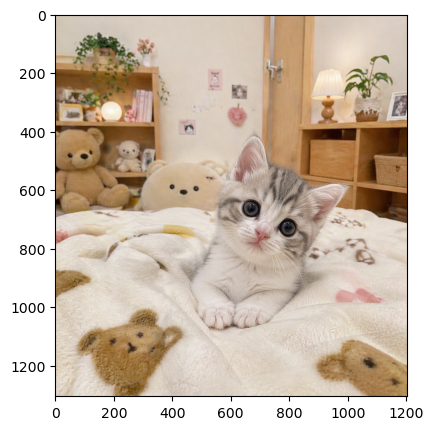

In [4]:
# 이미지 불러오기 (BGR → RGB)
cat_img_path = "/home/jovyan/work/cat.png" 
cat_img = cv2.imread(cat_img_path)

# OpenCV는 BGR이라서 RGB로 변환 (이후는 계속 RGB 유지!)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.show()


In [9]:
# segmentation 모델 불러오기
model = deeplabv3_resnet101(pretrained=True).eval()

In [10]:
# 모델 입력용 전처리
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

In [12]:
input_tensor = transform(cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [13]:
# segmentation 수행
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: user 9.65 s, sys: 19 ms, total: 9.66 s
Wall time: 9.72 s


In [15]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep'
]
len(LABEL_NAMES)

18

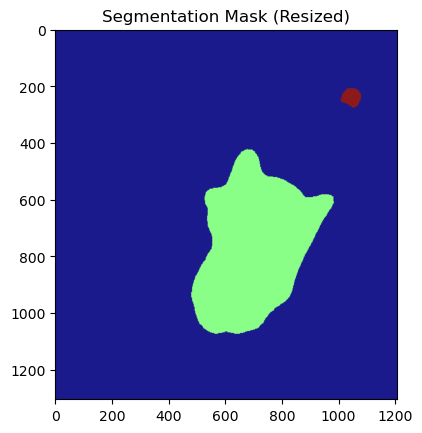

In [21]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.9)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [48]:
unique_classes = np.unique(output_predictions_resized)
unique_classes


array([ 0,  8, 16], dtype=uint8)

In [23]:
# 이미지에 어떤 객체들이 있는지 확인
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
cat
pottedplant


In [34]:
# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:17]  # 생성한 18개의 컬러맵 출력 

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0]])

In [35]:
colormap[8] #컬러맵 8에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES 8번째인 사람)

array([64,  0,  0])

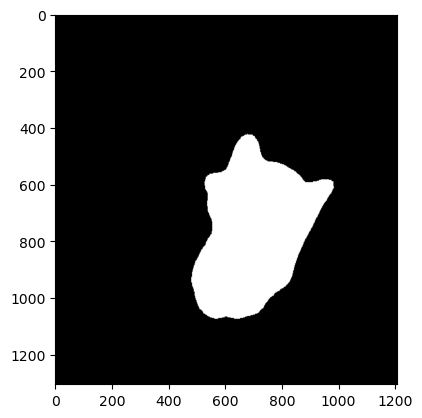

In [36]:
# output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다
# 1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = (output_predictions_resized == 8)  # 클래스 ID 8 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

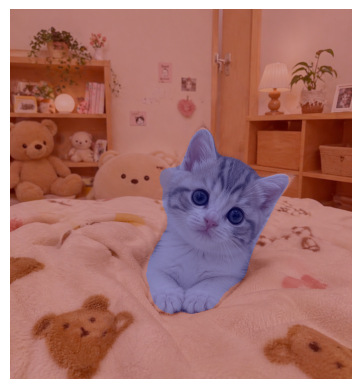

In [54]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.

img_show = cv2.addWeighted(cat_img, 0.6, color_mask, 0.4, 0.0)

plt.imshow(img_show)   # ❗ cvtColor 제거
plt.axis('off')
plt.show()

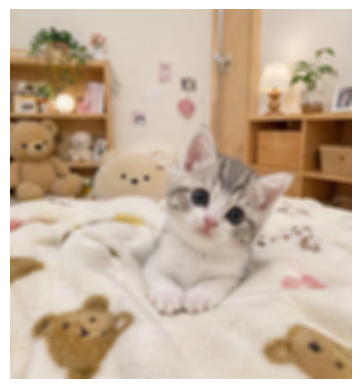

In [64]:
# (20,20)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_orig_blur = cv2.blur(cat_img, (19, 19))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)

plt.imshow(img_orig_blur)   # ✅ 그대로 출력
plt.axis('off')
plt.show()

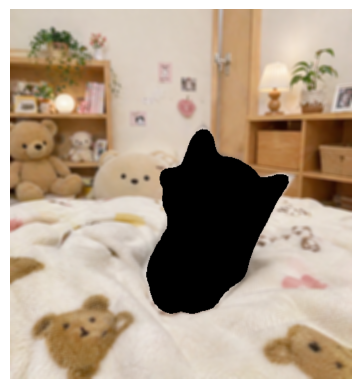

In [65]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
plt.imshow(img_bg_blur)   # ✅ 변환 없음
plt.axis('off')
plt.show()

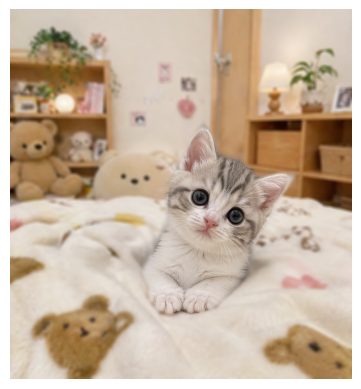

In [66]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, cat_img, img_bg_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(img_concat)
plt.axis('off')
plt.show()

In [67]:
이번 프로젝트에서는 이미지 세그멘테이션을 활용해 고양이만 분리하고 배경을 블러 처리했다. 
마스크와 컬러맵의 차이를 구분하며, 실제 연산에는 마스크 데이터가 핵심이라는 점을 배웠다.
최종적으로 np.where를 활용해 고양이는 유지하고 배경만 자연스럽게 합성하는 과정을 구현할 수 있었다.

SyntaxError: invalid syntax (2285959032.py, line 1)